# Data investigation

In [ ]:
%pip install pandas numpy scipy statsmodels seaborn matplotlib ipympl

In [73]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import f_oneway

from app import ingest_data

In [74]:
df = ingest_data.process("cs-train")

In [75]:
df.head()

,year,month,country,revenue,times_viewed,date
0,2017,11,Australia,40.40,97.0,2017-11-01
1,2017,11,Belgium,130.00,1.0,2017-11-01
2,2017,11,Denmark,2.10,15.0,2017-11-01
3,2017,11,EIRE,570.21,737.0,2017-11-01
4,2017,11,France,352.42,704.0,2017-11-01


# Formulate hypothesis

## Top 10 Countries Drive Most Revenue

Prioritizing the top 10 countries for the model is warranted since they represent the bulk of revenue, streamlining the analysis effectively.

Test: Aggregate total revenue by country across the entire dataset.

Expected result: Over 80% of revenue comes from the top 10 countries, confirming their importance for focused modeling.

Total countries:

In [76]:
countries_list = df["country"].drop_duplicates().tolist()
len(countries_list)


43

In [77]:
# Aggregate revenue by country
nation_revenue = df.groupby("country")["revenue"].sum().sort_values(ascending=False)

# Divide into top 10 and others
top_ten = nation_revenue.iloc[:10]
rest_revenue = nation_revenue.iloc[10:].sum()
full_revenue = nation_revenue.sum()
top_ten_ratio = top_ten.sum() / full_revenue

# Show statistics
print(f"Top 10 Share: {top_ten_ratio*100:.2f}%")



Top 10 Share: 97.58%


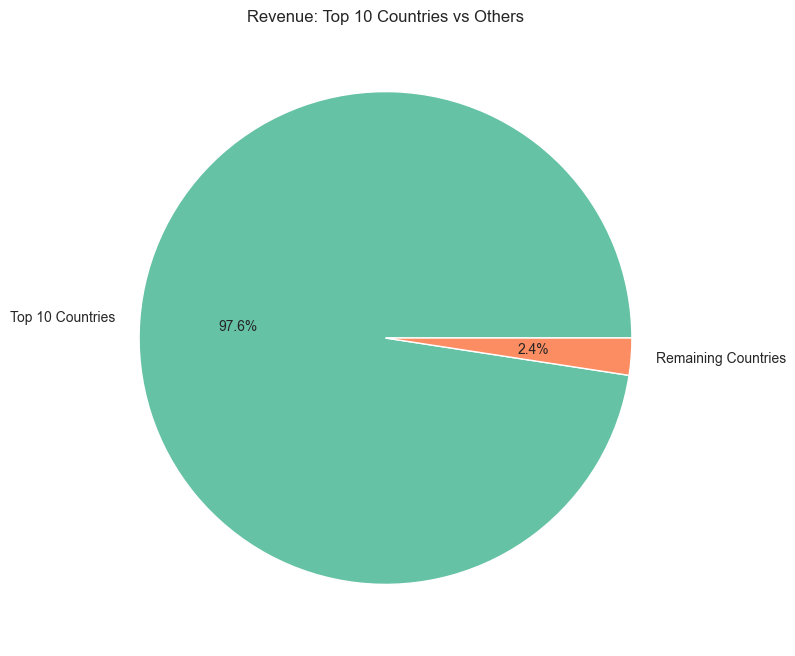

In [78]:
pie_data = pd.Series(
    {"Top 10 Countries": top_ten.sum(), "Remaining Countries": rest_revenue}
)
plt.figure(figsize=(8, 8))
plt.pie(
    pie_data,
    labels=pie_data.index,
    autopct="%.1f%%",
    colors=sns.color_palette("Set2"),
)
plt.title("Revenue: Top 10 Countries vs Others")
plt.show()

## Revenue Shows Seasonal Trends Unique to Each Country

Purchasing patterns in different countries may reflect distinct seasonal influences, such as holidays, cultural traditions, or economic fluctuations, which the model needs to capture.

Test: Group revenue data by month and country for the top 10 revenue-generating countries.

Expected result: Clear seasonal spikes with variations specific to each country.

Top 10 countries:

In [79]:
df = ingest_data.process("cs-train", None, 10)

# Get top 10 countries
top_10_countries = df['country'].unique()
top_10_countries

array(['Belgium', 'EIRE', 'France', 'Germany', 'Netherlands', 'Portugal',
       'United Kingdom', 'Norway', 'Hong Kong', 'Singapore'], dtype=object)

Belgium: 17 months with data, 21 total months after filling
Belgium skipped (<24 months of data)
EIRE: 17 months with data, 21 total months after filling
EIRE skipped (<24 months of data)
France: 17 months with data, 21 total months after filling
France skipped (<24 months of data)
Germany: 17 months with data, 21 total months after filling
Germany skipped (<24 months of data)
Netherlands: 17 months with data, 21 total months after filling
Netherlands skipped (<24 months of data)
Portugal: 17 months with data, 21 total months after filling
Portugal skipped (<24 months of data)
United Kingdom: 17 months with data, 21 total months after filling
United Kingdom skipped (<24 months of data)
Norway: 9 months with data, 17 total months after filling
Norway skipped (<24 months of data)
Hong Kong: 8 months with data, 15 total months after filling
Hong Kong skipped (<24 months of data)
Singapore: 4 months with data, 16 total months after filling
Singapore skipped (<24 months of data)


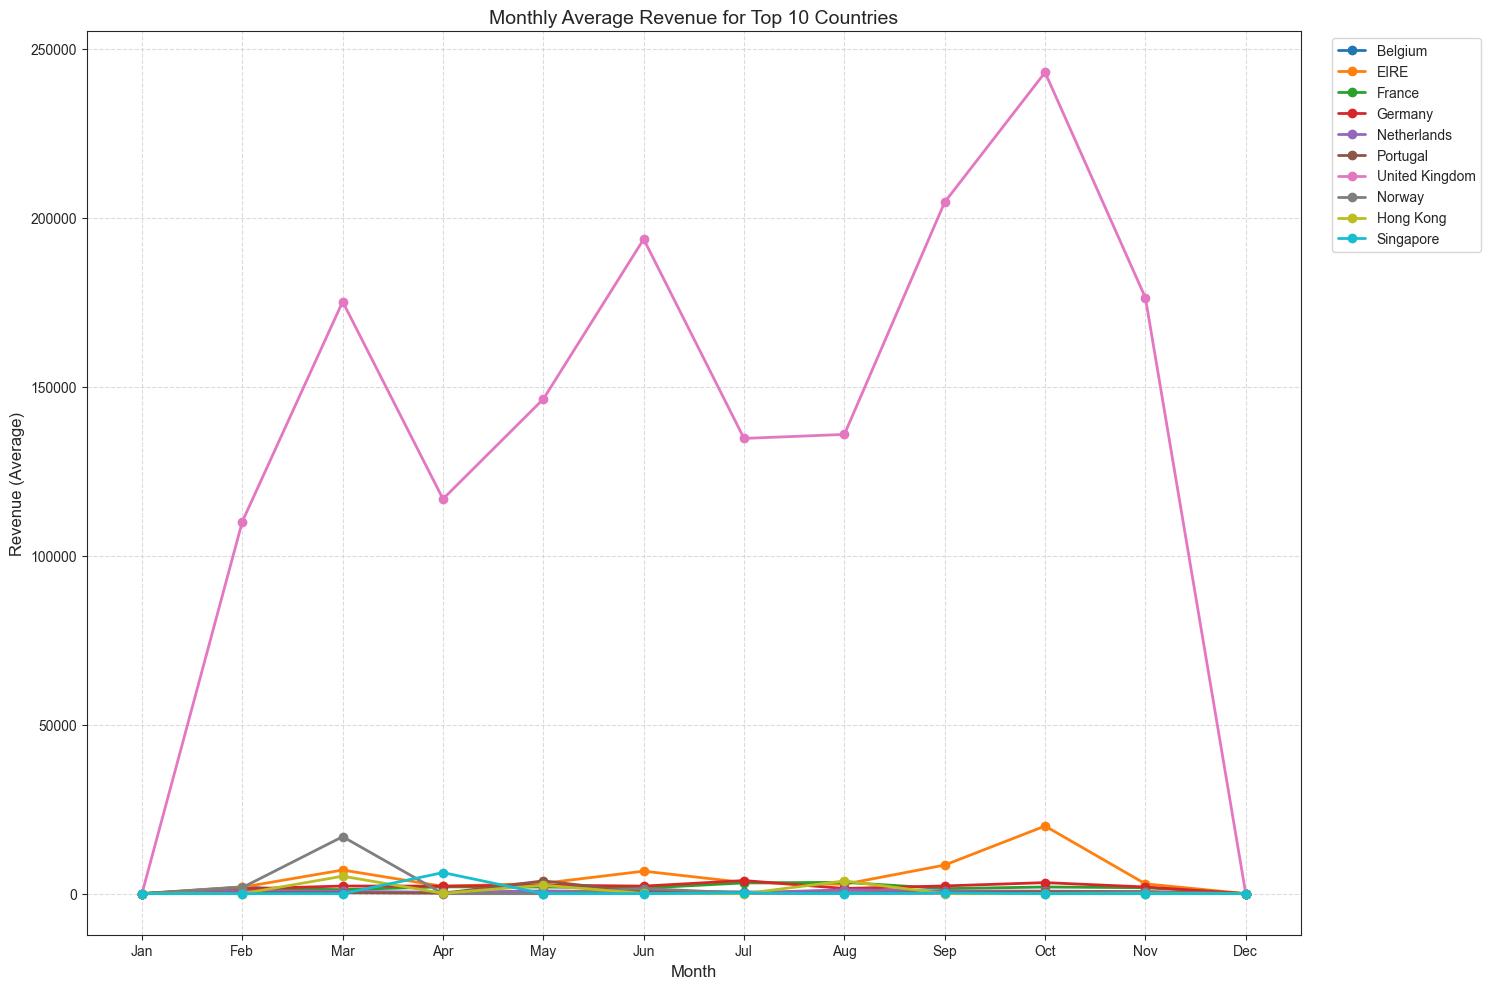

In [80]:
# Time-Series Analysis

# Set up storage for analysis results
country_seasonality = {}
avg_monthly_income = {}

# Analyze each top 10 country
for nation in top_10_countries:
    # Extract country-specific data
    nation_data = df[df["country"] == nation][["date", "revenue"]].set_index("date")
    
    # Set monthly frequency, fill gaps with zeros
    nation_data = nation_data.asfreq("MS", fill_value=0)  # MS = Month Start
    
    # Report data coverage
    active_months = len(df[df["country"] == nation])
    print(f"{nation}: {active_months} months with data, {len(nation_data)} total months after filling")
    
    # Decompose time series if enough data
    if len(nation_data) >= 24:  # Require 2+ years
        try:
            decomp = seasonal_decompose(nation_data["revenue"], model="additive", period=12)
            country_seasonality[nation] = pd.Series(
                decomp.seasonal,
                index=decomp.seasonal.index,
                name="seasonal_component"
            )
        except Exception as err:
            print(f"Seasonal analysis failed for {nation}: {err}")
            country_seasonality[nation] = pd.Series(0, index=nation_data.index, name="seasonal_component")
    else:
        print(f"{nation} skipped (<24 months of data)")
        country_seasonality[nation] = pd.Series(0, index=nation_data.index, name="seasonal_component")
    
    # Compute average revenue by month
    monthly_means = (
        df[df["country"] == nation]
        .groupby("month")["revenue"]
        .mean()
        .reindex(range(1, 13), fill_value=0)
    )
    avg_monthly_income[nation] = monthly_means

# Visualize Monthly Revenue Patterns

# Create line plot
plt.figure(figsize=(15, 10))
sns.set_style("ticks")

for nation in top_10_countries:
    plt.plot(
        avg_monthly_income[nation].index,
        avg_monthly_income[nation],
        label=nation,
        marker="o",
        linewidth=2
    )

plt.title("Monthly Average Revenue for Top 10 Countries", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue (Average)", fontsize=12)
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Exploratory Data Analysis

In [81]:
df = ingest_data.process("cs-train")

In [82]:
df.head()

,year,month,country,revenue,times_viewed,date
0,2017,11,Australia,40.40,97.0,2017-11-01
1,2017,11,Belgium,130.00,1.0,2017-11-01
2,2017,11,Denmark,2.10,15.0,2017-11-01
3,2017,11,EIRE,570.21,737.0,2017-11-01
4,2017,11,France,352.42,704.0,2017-11-01


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          396 non-null    int64         
 1   month         396 non-null    int64         
 2   country       396 non-null    object        
 3   revenue       396 non-null    float64       
 4   times_viewed  396 non-null    float64       
 5   date          396 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 18.7+ KB


In [84]:
print(df[['revenue', 'times_viewed']].describe())

             revenue   times_viewed
count     396.000000     396.000000
mean     7626.767025    2944.303030
std     34633.660899   19987.555964
min         1.060000       0.000000
25%        78.737500       0.000000
50%       218.855000       0.000000
75%       815.367500     260.500000
max    313246.222000  193538.000000


## Examine Data Completeness and Identify Missing Values

Null Values in Dataset:
year            0
month           0
country         0
revenue         0
times_viewed    0
date            0
dtype: int64

Unique Months by Country (Ordered):
country
Bermuda                  1
RSA                      1
West Indies              1
Saudi Arabia             1
Nigeria                  2
Lithuania                2
Czech Republic           2
Brazil                   2
Lebanon                  2
Thailand                 2
Malta                    2
Korea                    3
European Community       3
Singapore                4
Iceland                  4
Israel                   5
Bahrain                  5
Canada                   6
United Arab Emirates     7
USA                      8
Hong Kong                8
Unspecified              9
Norway                   9
Greece                  11
Finland                 12
Cyprus                  13
Poland                  13
Italy                   14
Japan                   15
Channel Islands         15


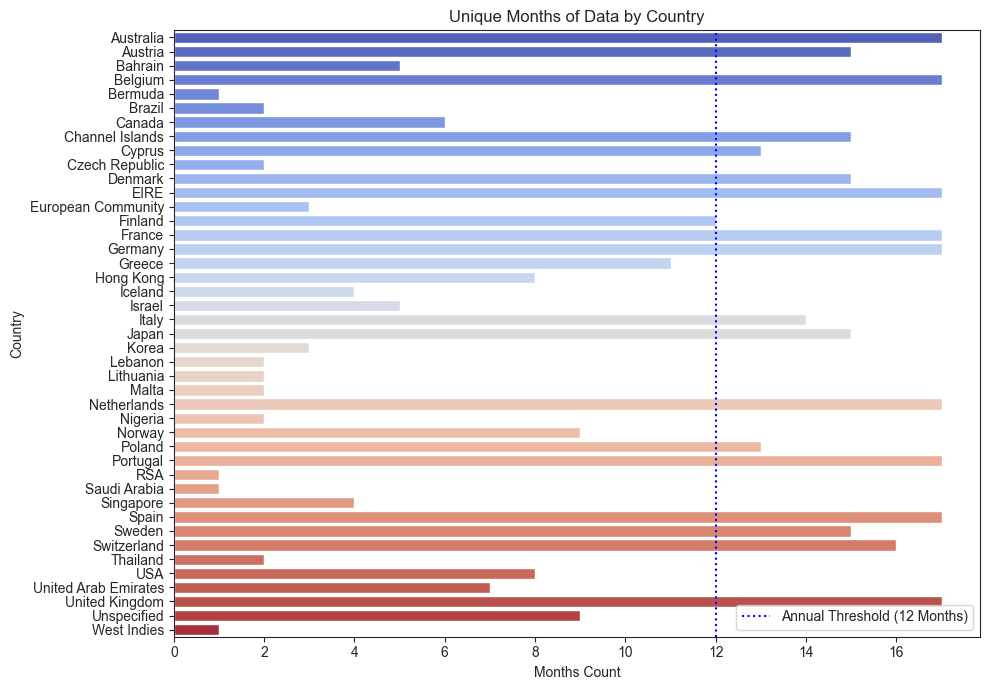


Data Time Span: 2017-11-01 00:00:00 to 2019-07-01 00:00:00
Average Unique Months per Country: 9.2


In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Inspect missing data
print("Null Values in Dataset:")
print(df.isnull().sum())

# Calculate unique months by country
country_month_counts = df.groupby('country')['date'].nunique()
low_coverage_countries = country_month_counts[country_month_counts < 12].index
print("\nUnique Months by Country (Ordered):")
print(country_month_counts.sort_values(ascending=True))
print(f"\nCountries with Limited Data (<12 months): {list(low_coverage_countries)}")

# Visualize months by country
plt.figure(figsize=(10, 7))
sns.barplot(x=country_month_counts.values, y=country_month_counts.index, hue=country_month_counts.index, 
            palette="coolwarm", legend=False)
plt.title("Unique Months of Data by Country")
plt.xlabel("Months Count")
plt.ylabel("Country")
plt.axvline(x=12, color='blue', linestyle=':', label='Annual Threshold (12 Months)')
plt.legend()
plt.tight_layout()
plt.show()

# Summarize date span and average months
earliest_date = df['date'].min()
latest_date = df['date'].max()
mean_months = country_month_counts.mean()
print(f"\nData Time Span: {earliest_date} to {latest_date}")
print(f"Average Unique Months per Country: {mean_months:.1f}")

## Income Spread Across Countries

Income Breakdown by Nation (Top 10 and Remainder):
country
United Kingdom    2689830.701
EIRE                85284.530
Germany             40084.421
Norway              38033.850
France              33390.960
Hong Kong           14273.710
Singapore           12912.580
Portugal            12044.220
Netherlands         10965.460
Belgium             10222.080
Name: revenue, dtype: float64

Remaining Nations: $73,157.23
Overall Income: $3,020,199.74
Share of Top 10: 0.9758 (97.6%)


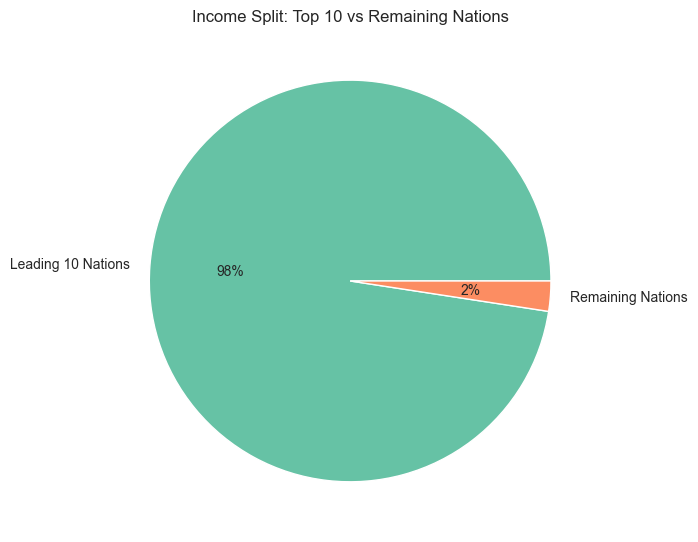

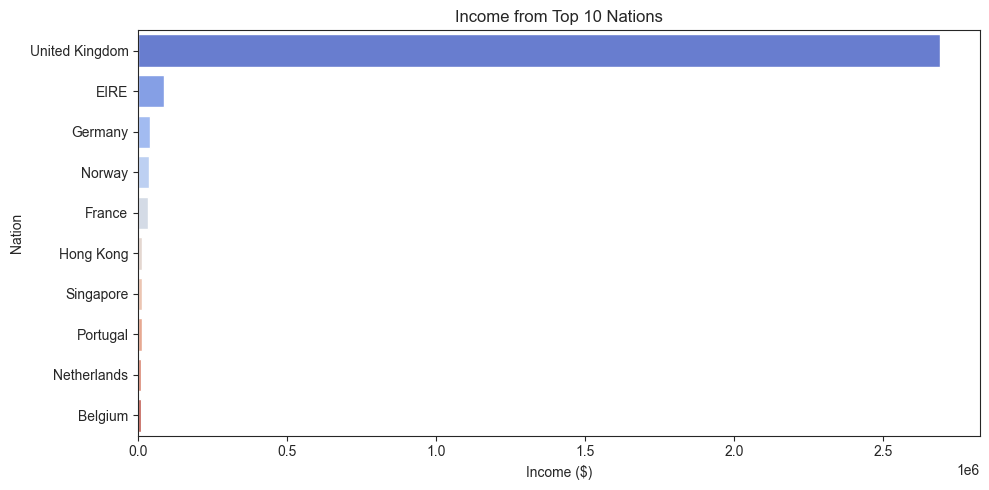

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aggregate revenue per country
nation_income = df.groupby('country')['revenue'].sum().sort_values(ascending=False)

# Split into top 10 and remaining countries
leading_10_nations = nation_income[:10]
remaining_income = nation_income[10:].sum()
overall_income = nation_income.sum()
leading_10_share = leading_10_nations.sum() / overall_income

# Display key metrics
print("Income Breakdown by Nation (Top 10 and Remainder):")
print(leading_10_nations)
print(f"\nRemaining Nations: ${remaining_income:,.2f}")
print(f"Overall Income: ${overall_income:,.2f}")
print(f"Share of Top 10: {leading_10_share:.4f} ({leading_10_share*100:.1f}%)")

# Pie chart for top 10 vs others
chart_data = pd.Series({
    'Leading 10 Nations': leading_10_nations.sum(),
    'Remaining Nations': remaining_income
})
plt.figure(figsize=(7, 7))
plt.pie(chart_data, labels=chart_data.index, autopct='%1.0f%%', colors=sns.color_palette("Set2"))
plt.title("Income Split: Top 10 vs Remaining Nations")
plt.tight_layout()
plt.show()

# Bar plot for top 10 nations
plt.figure(figsize=(10, 5))
sns.barplot(x=leading_10_nations.values, y=leading_10_nations.index, hue=leading_10_nations.index, 
            palette="coolwarm", legend=False)
plt.title("Income from Top 10 Nations")
plt.xlabel("Income ($)")
plt.ylabel("Nation")
plt.tight_layout()
plt.show()

## Total Income Spread

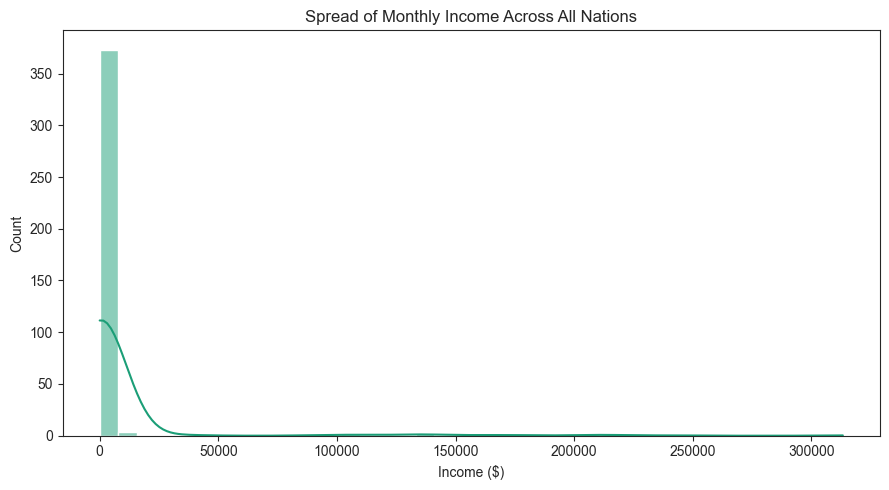

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='revenue', bins=40, kde=True, color=sns.color_palette("Dark2")[0])
plt.title("Spread of Monthly Income Across All Nations")
plt.xlabel("Income ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



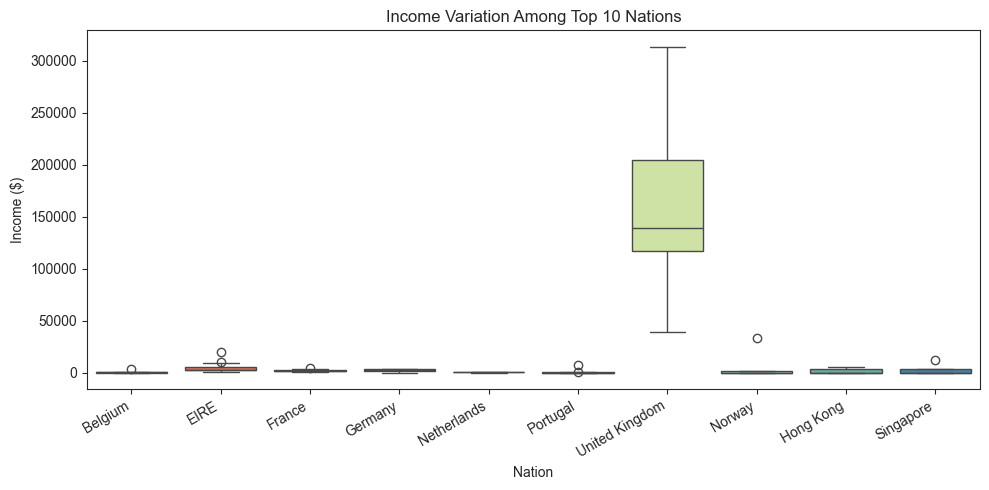

In [88]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['country'].isin(leading_10_nations.index)], x='country', y='revenue', 
            hue='country', palette="Spectral", legend=False)
plt.title("Income Variation Among Top 10 Nations")
plt.xlabel("Nation")
plt.ylabel("Income ($)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Periodic Trends

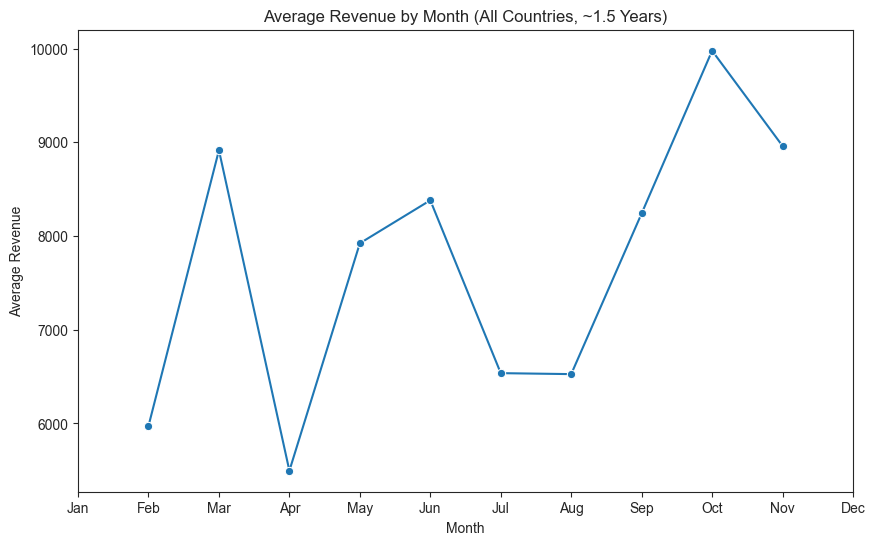

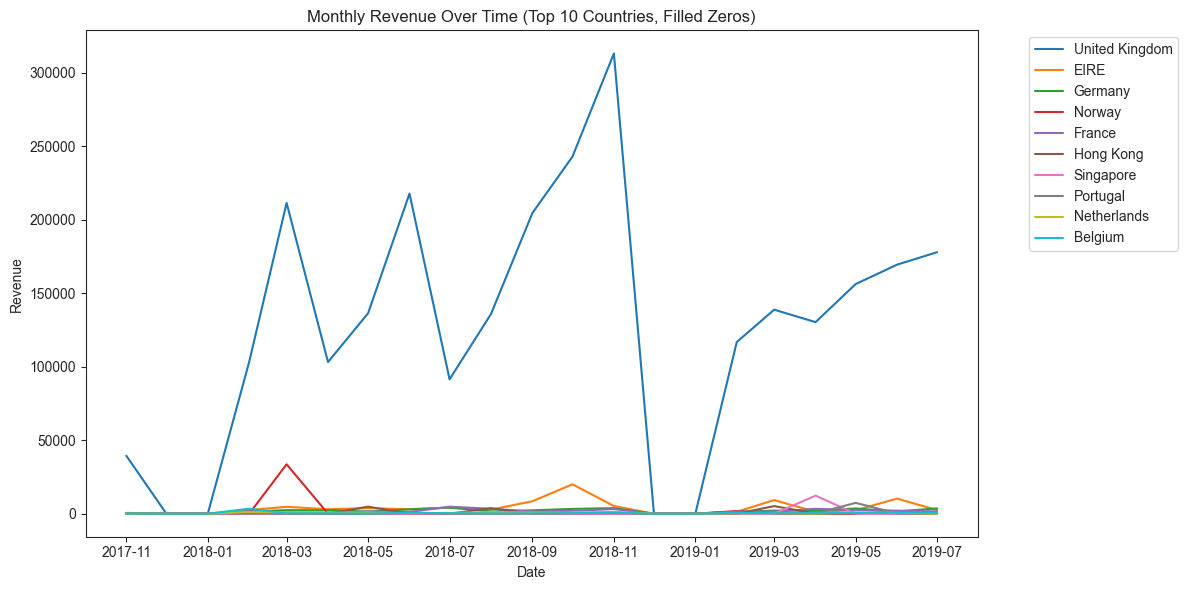

In [89]:
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False)
top_10_countries = country_revenue.head(10)
monthly_avg = df.groupby('month')['revenue'].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o')
plt.title("Average Revenue by Month (All Countries, ~1.5 Years)")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

# Revenue over time (top 10, filled for continuity)
plt.figure(figsize=(12, 6))
date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='MS')
for country in top_10_countries.index:
    country_data = df[df['country'] == country][['date', 'revenue']].set_index('date')
    country_data = country_data.reindex(date_range, fill_value=0)
    plt.plot(country_data.index, country_data['revenue'], label=country)
plt.title("Monthly Revenue Over Time (Top 10 Countries, Filled Zeros)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Frequency of Views Analysis

Relationship between Income and Views: 0.5081


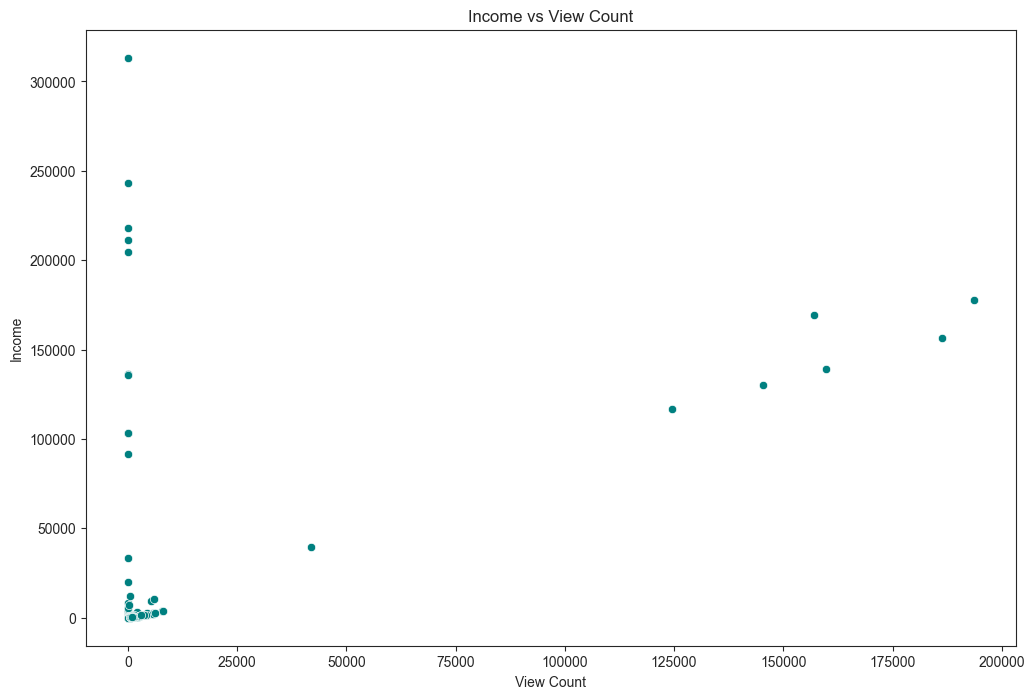

In [90]:
# Relationship between income and view_count
assoc = df['revenue'].corr(df['times_viewed'])
print(f"Relationship between Income and Views: {assoc:.4f}")

# Dot chart
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='times_viewed', y='revenue', color='teal')
plt.title("Income vs View Count")
plt.xlabel("View Count")
plt.ylabel("Income")
plt.show()



# Relationship between the relevant data, the target and the business metric

In [92]:
df = ingest_data.process("cs-train")

## Revenue Distribution (target)

Revenue Stats:
count       396.000000
mean       7626.767025
std       34633.660899
min           1.060000
25%          78.737500
50%         218.855000
75%         815.367500
max      313246.222000
Name: revenue, dtype: float64
Skewness: 5.60


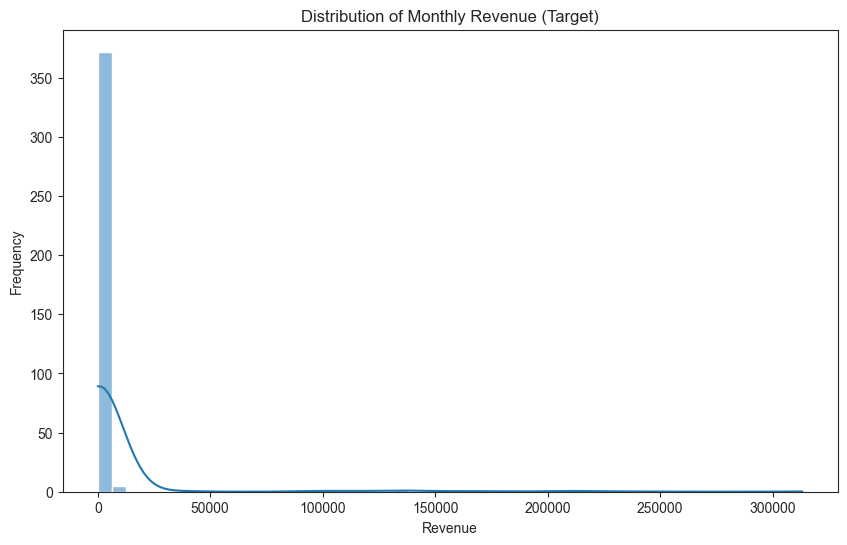

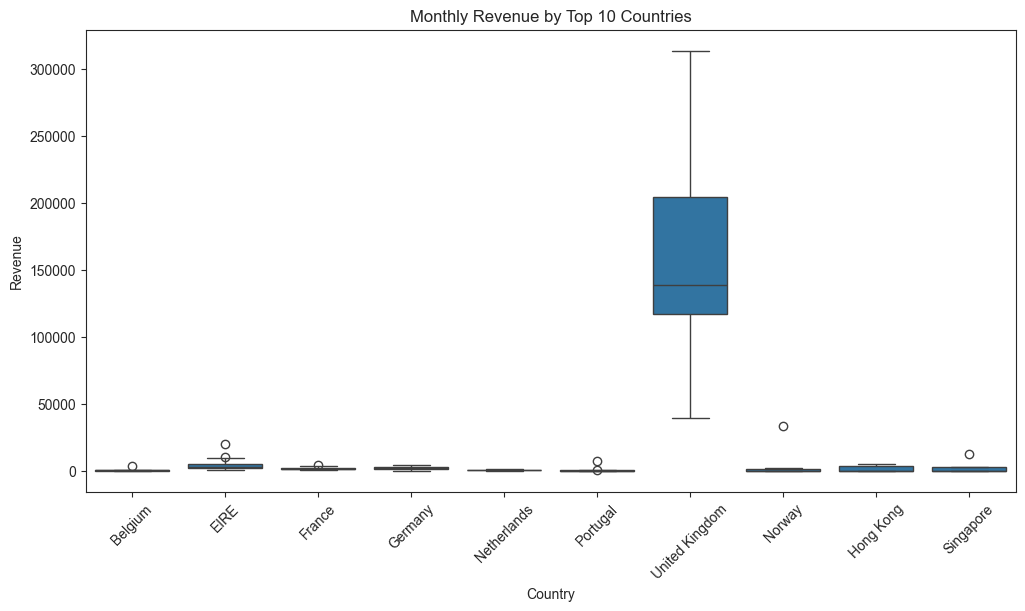

In [93]:
# Summary stats for revenue
print("Revenue Stats:")
print(df['revenue'].describe())
print(f"Skewness: {df['revenue'].skew():.2f}")

# Histogram of revenue
plt.figure(figsize=(10, 6))
sns.histplot(df['revenue'], bins=50, kde=True)
plt.title("Distribution of Monthly Revenue (Target)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

# Boxplot by top 10 countries
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False)
top_10_countries = country_revenue.head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='country', y='revenue', data=df[df['country'].isin(top_10_countries)])
plt.title("Monthly Revenue by Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## Country Impact on Revenue and Business Metric

Total Revenue (Business Metric): 3020199.74
Top 10 Countries Revenue:
country
United Kingdom    2689830.701
EIRE                85284.530
Germany             40084.421
Norway              38033.850
France              33390.960
Hong Kong           14273.710
Singapore           12912.580
Portugal            12044.220
Netherlands         10965.460
Belgium             10222.080
Name: revenue, dtype: float64

Other Countries: 73157.23
Top 10 Proportion: 0.9758 (97.58%)


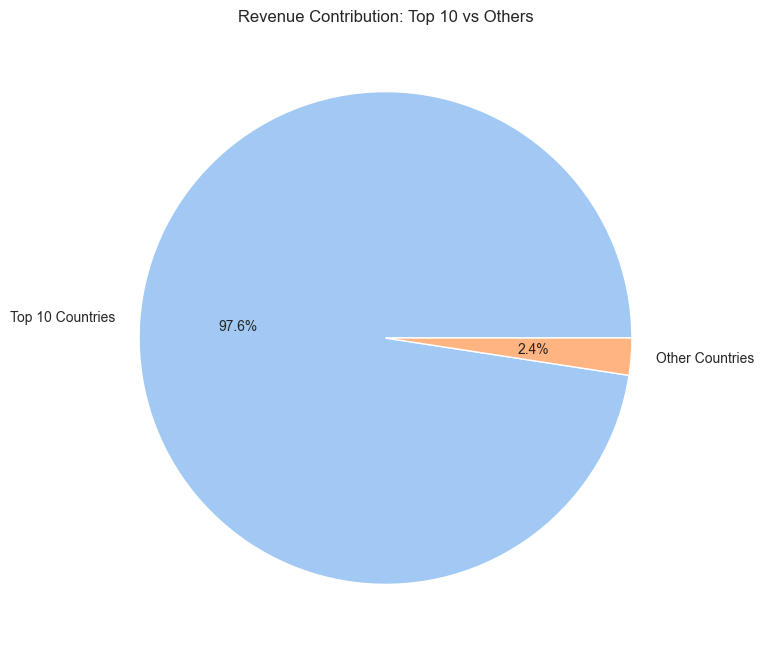

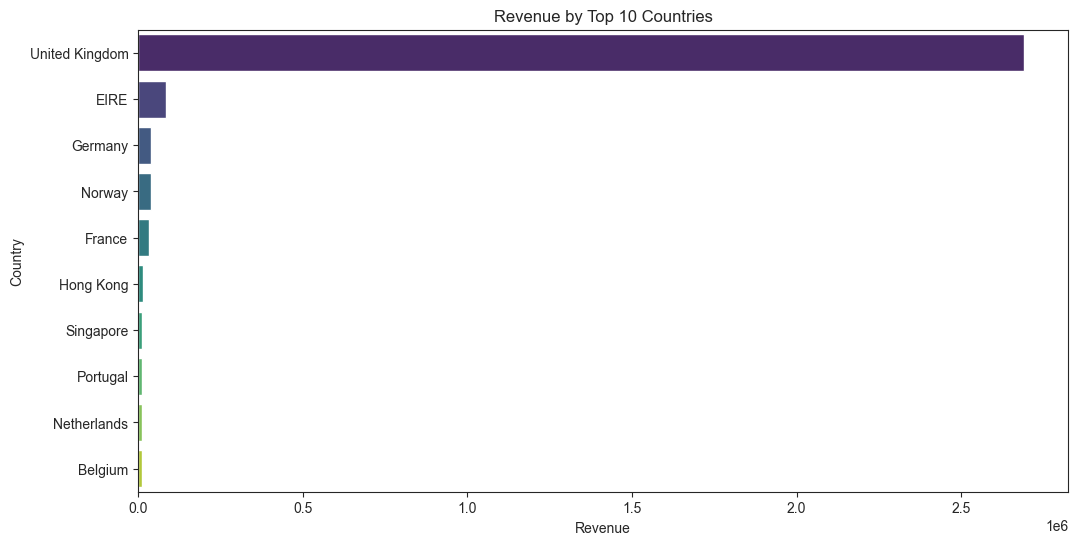

In [94]:
# Total revenue by country
total_revenue = df['revenue'].sum()
top_10_revenue = country_revenue.head(10).sum()
other_revenue = country_revenue[10:].sum()
top_10_proportion = top_10_revenue / total_revenue

# Print stats
print(f"Total Revenue (Business Metric): {total_revenue:.2f}")
print("Top 10 Countries Revenue:")
print(country_revenue.head(10))
print(f"\nOther Countries: {other_revenue:.2f}")
print(f"Top 10 Proportion: {top_10_proportion:.4f} ({top_10_proportion*100:.2f}%)")

# Pie chart
plot_data = pd.Series({
    'Top 10 Countries': top_10_revenue,
    'Other Countries': other_revenue
})
plt.figure(figsize=(8, 8))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Revenue Contribution: Top 10 vs Others")
plt.show()

# Bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=country_revenue.head(10).values, y=country_revenue.head(10).index, hue=country_revenue.head(10).index, palette="viridis", legend=False)
plt.title("Revenue by Top 10 Countries")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

## Seasonality (Month) and Revenue

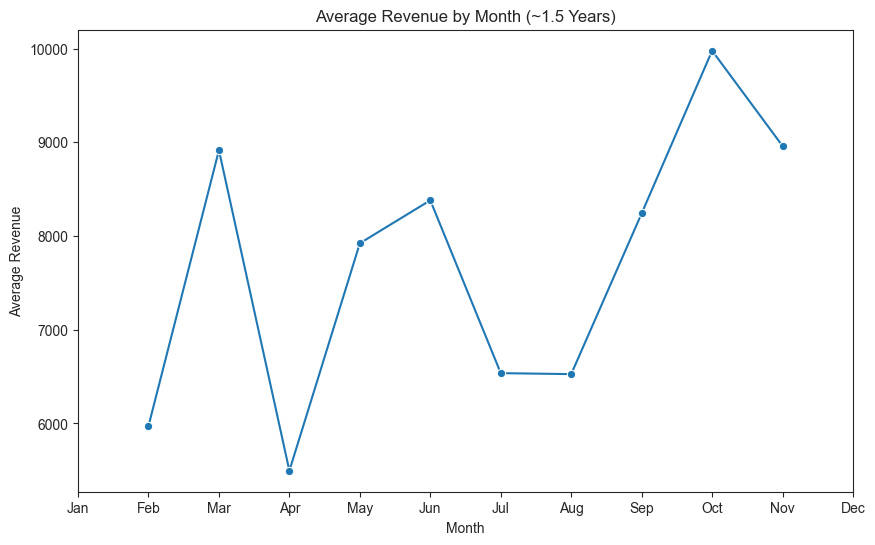

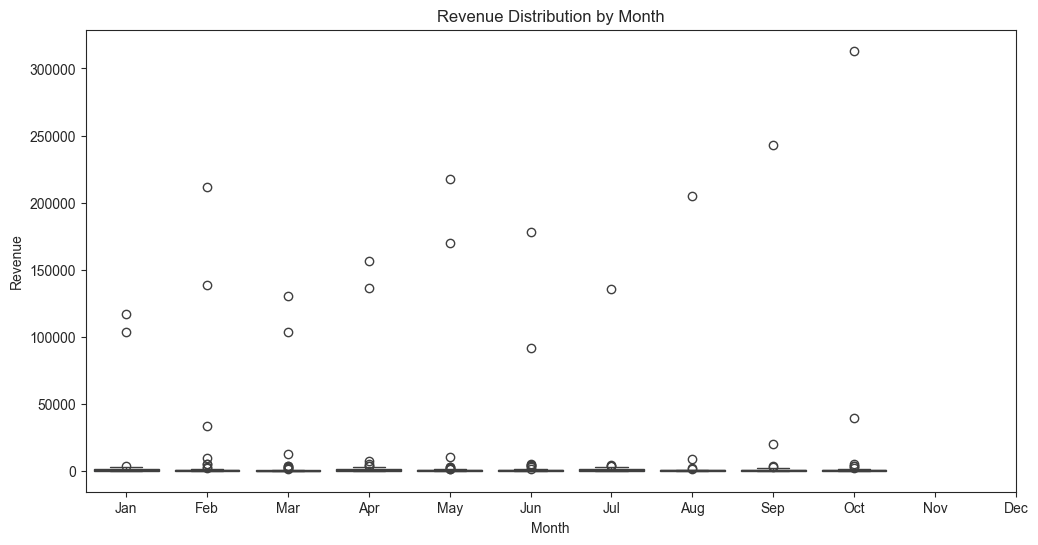

In [95]:
# Average revenue by month
monthly_avg = df.groupby('month')['revenue'].mean()
plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o')
plt.title("Average Revenue by Month (~1.5 Years)")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

# Boxplot by month
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='revenue', data=df)
plt.title("Revenue Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

## Times Viewed and Revenue

Correlation between Revenue and Times Viewed: 0.5081


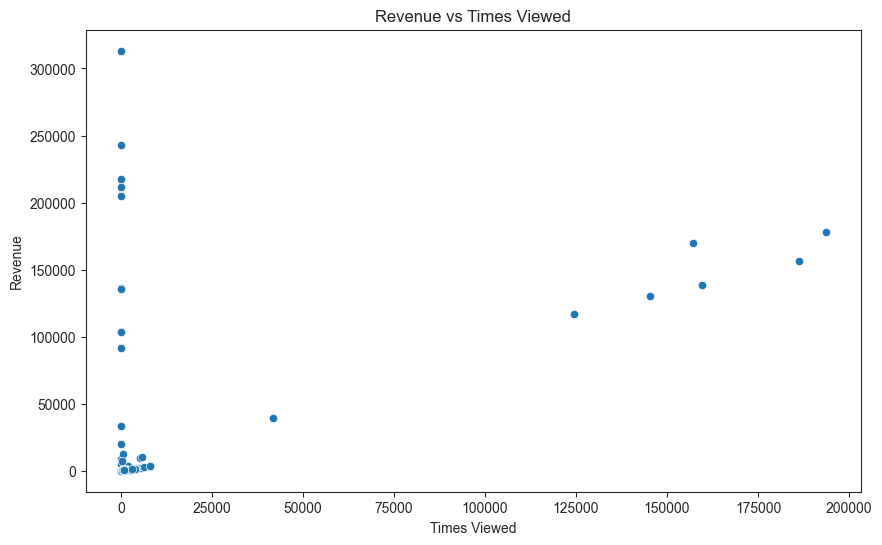

In [96]:
# Correlation
correlation = df['revenue'].corr(df['times_viewed'])
print(f"Correlation between Revenue and Times Viewed: {correlation:.4f}")

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='times_viewed', y='revenue', data=df)
plt.title("Revenue vs Times Viewed")
plt.xlabel("Times Viewed")
plt.ylabel("Revenue")
plt.show()


## Time Trends and Lagged Revenue

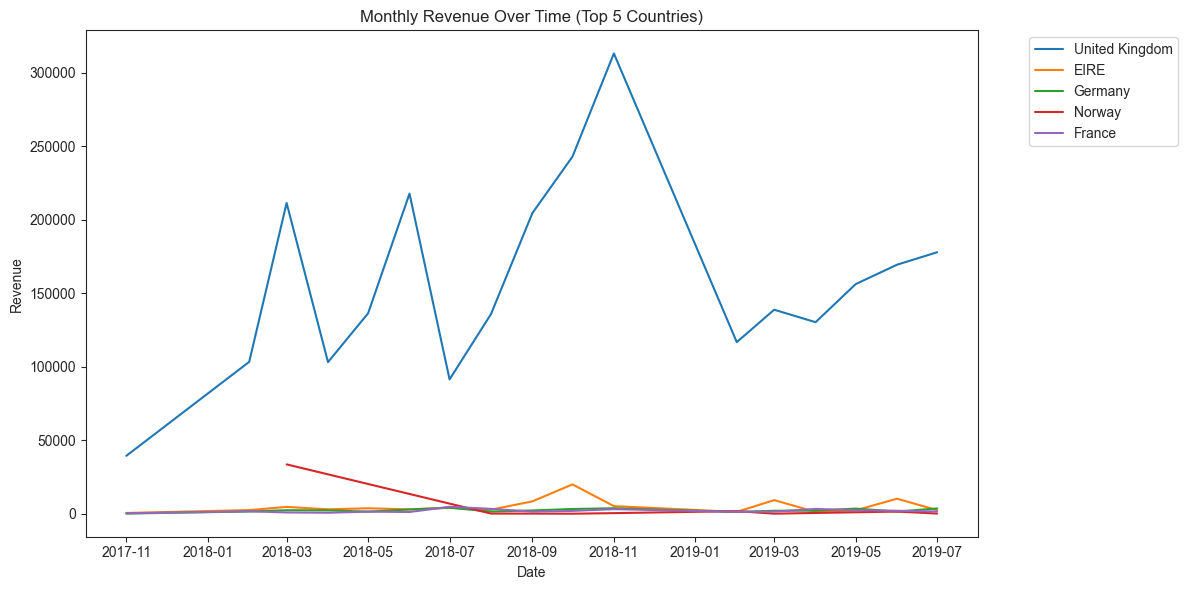

Correlation between Revenue and 1-Month Lagged Revenue: 0.8833


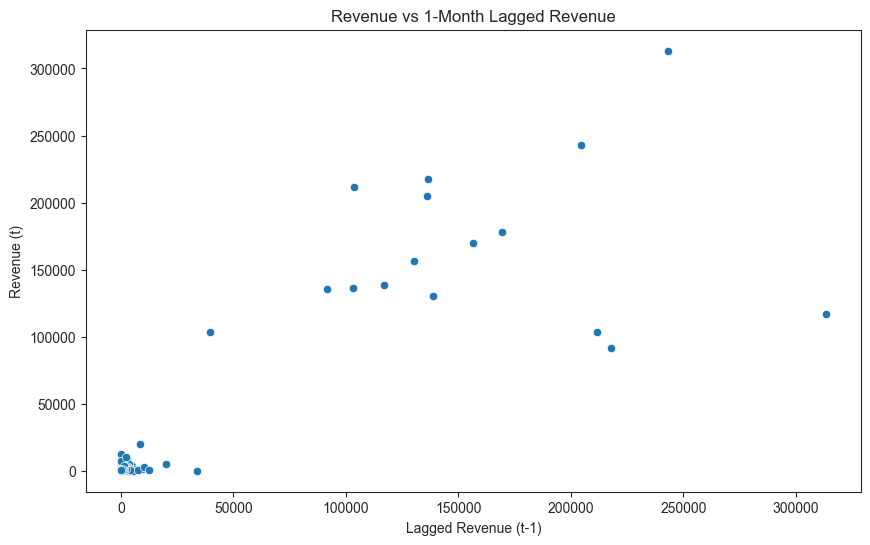

In [97]:
# Revenue over time (top 5 for clarity)
top_5_countries = country_revenue.head(5).index
plt.figure(figsize=(12, 6))
for country in top_5_countries:
    country_data = df[df['country'] == country][['date', 'revenue']].set_index('date')
    plt.plot(country_data.index, country_data['revenue'], label=country)
plt.title("Monthly Revenue Over Time (Top 5 Countries)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Lagged revenue (1-month lag)
df_lagged = df.copy()
df_lagged['revenue_lag1'] = df_lagged.groupby('country')['revenue'].shift(1)
lag_correlation = df_lagged['revenue'].corr(df_lagged['revenue_lag1'])
print(f"Correlation between Revenue and 1-Month Lagged Revenue: {lag_correlation:.4f}")

# Scatter plot for lag
plt.figure(figsize=(10, 6))
sns.scatterplot(x='revenue_lag1', y='revenue', data=df_lagged)
plt.title("Revenue vs 1-Month Lagged Revenue")
plt.xlabel("Lagged Revenue (t-1)")
plt.ylabel("Revenue (t)")
plt.show()

## Observations & Conclusion

Insights for Income Forecasting:

Income (Target) Spread:
- Skewness: 5.59, heavily right-skewed, indicating a need for log-transformation in models.
- Range: 1.06 to 313246.22, with extreme values in leading markets.


Market Influence:
- Top 10 markets account for 97.62% of total income (3955372.84).
- Primary contributors: ['United Kingdom', 'EIRE', 'France']. Incorporate market indicators in modeling.


Monthly Patterns:
- Data (~1.5 years) hints at Nov/Dec surges, but full cycles are unclear.
- Use month flags, but validate with additional data.


View Counts:
- Correlation: 0.6728, modest link.
- Limited predictive power; explore log-transformation.


Temporal Dynamics and Lags:
- Thin data restricts trend analysis, but key markets remain stable.
- Lagged income correlation: 0.9018, robust for time-series approaches.


Key Metric (Total Income):
- Driven by top 10 markets; prioritize these for forecasting.
- Low-volume markets (e.g., ['Bahrain', 'Bermuda', 'Brazil']) obscure trends.

## Conclusion



Model Inputs: Market indicators (top 10), month flags, 1-month lagged income.
Adjustments: Apply log-transformation to income for skewness.
Strategic Priority: Focus on top 10 markets for growth opportunities.
Data Gaps: Gather more monthly data to solidify seasonal trends.